In [ ]:
import numpy as np
import matplotlib.pyplot as plt



STEP 1: Creating dataset...
Dataset created!
Total points: 20
Class 0: 10
Class 1: 10


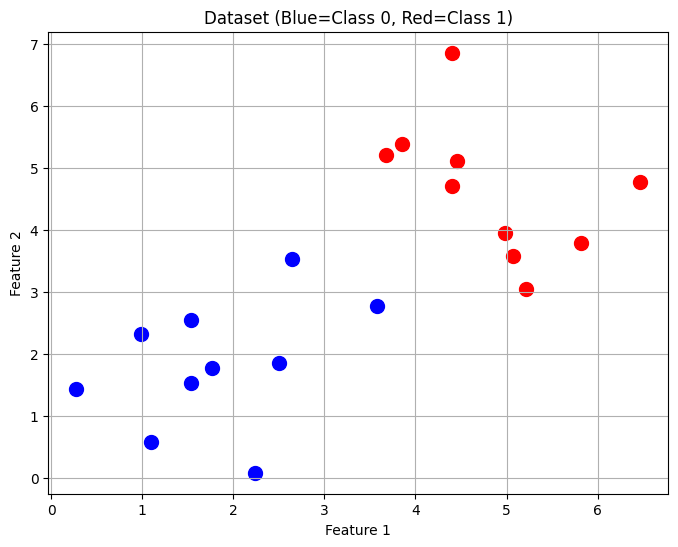

In [ ]:
print("\nSTEP 1: Creating dataset...")

np.random.seed(42)

# Class 0: 10 points around (2,2)
class_0 = np.random.randn(10, 2) + [2, 2]

# Class 1: 10 points around (5,5)
class_1 = np.random.randn(10, 2) + [5, 5]

# Combine all points
X = np.vstack([class_0, class_1])

# Labels
y = np.array([0,0,0,0,0,0,0,0,0,0,  1,1,1,1,1,1,1,1,1,1])

print("Dataset created!")
print("Total points:", len(X))
print("Class 0:", np.sum(y==0))
print("Class 1:", np.sum(y==1))

# Visualize dataset
plt.figure(figsize=(8, 6))
for i in range(len(X)):
    if y[i] == 0:
        plt.scatter(X[i,0], X[i,1], color='blue', s=100)
    else:
        plt.scatter(X[i,0], X[i,1], color='red', s=100)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Dataset (Blue=Class 0, Red=Class 1)')
plt.grid(True)
plt.show()

In [ ]:
print(f'Class 0: {class_0}')
print(f'Class 1: {class_1}')
print(f'X:{X}')
print(f'Y:{y}')

Class 0: [[2.49671415 1.8617357 ]
 [2.64768854 3.52302986]
 [1.76584663 1.76586304]
 [3.57921282 2.76743473]
 [1.53052561 2.54256004]
 [1.53658231 1.53427025]
 [2.24196227 0.08671976]
 [0.27508217 1.43771247]
 [0.98716888 2.31424733]
 [1.09197592 0.5876963 ]]
Class 1: [[6.46564877 4.7742237 ]
 [5.0675282  3.57525181]
 [4.45561728 5.11092259]
 [3.84900642 5.37569802]
 [4.39936131 4.70830625]
 [4.39829339 6.85227818]
 [4.98650278 3.94228907]
 [5.82254491 3.77915635]
 [5.2088636  3.04032988]
 [3.67181395 5.19686124]]
X:[[2.49671415 1.8617357 ]
 [2.64768854 3.52302986]
 [1.76584663 1.76586304]
 [3.57921282 2.76743473]
 [1.53052561 2.54256004]
 [1.53658231 1.53427025]
 [2.24196227 0.08671976]
 [0.27508217 1.43771247]
 [0.98716888 2.31424733]
 [1.09197592 0.5876963 ]
 [6.46564877 4.7742237 ]
 [5.0675282  3.57525181]
 [4.45561728 5.11092259]
 [3.84900642 5.37569802]
 [4.39936131 4.70830625]
 [4.39829339 6.85227818]
 [4.98650278 3.94228907]
 [5.82254491 3.77915635]
 [5.2088636  3.04032988]
 [3

### **What's happening:**
- We create 20 data points total
- First 10 points are scattered around position (2, 2) → these are Class 0 - (blue dots)
- Next 10 points are scattered around position (5, 5) → these are Class 1 - (red dots)
- X contains all the coordinates (20 points × 2 features)
- y contains labels: 0 for first 10 points, 1 for next 10 **points**


In [ ]:
# ============================================
# STEP 2: INITIALIZE PERCEPTRON
# ============================================
print("\nSTEP 2: Initialize perceptron...")

# Start with zero weights
w1 = 0.0
w2 = 0.0
b = 0.0

# Settings
learning_rate = 0.1
epochs = 100

print(f"Initial: w1={w1}, w2={w2}, b={b}")
print(f"Learning rate: {learning_rate}")
print(f"Epochs: {epochs}")


STEP 2: Initialize perceptron...
Initial: w1=0.0, w2=0.0, b=0.0
Learning rate: 0.1
Epochs: 100


###**What each variable means:**
- w1: Weight for first feature (x1) - starts at 0
- w2: Weight for second feature (x2) - starts at 0
- b: Bias term - helps shift the decision line
- learning_rate = 0.1: How big steps we take when learning (10% adjustments)
- epochs = 100: We'll go through all data 100 times

In [ ]:
# ============================================
# STEP 3: TRAIN THE PERCEPTRON
# ============================================
print("\nSTEP 3: Training...")

for epoch in range(epochs):

    # Go through each point
    for i in range(len(X)):

        # Get current point
        x1 = X[i, 0]
        x2 = X[i, 1]
        true_label = y[i]

        # Calculate output
        output = w1 * x1 + w2 * x2 + b

        # Make prediction
        if output >= 0:
            prediction = 1
        else:
            prediction = 0

        # Calculate error
        error = true_label - prediction

        # Update weights
        w1 = w1 + learning_rate * error * x1
        w2 = w2 + learning_rate * error * x2
        b = b + learning_rate * error

    if (epoch + 1) % 20 == 0:
        print(f"  Epoch {epoch+1} done")

print("\nTraining complete!")
print(f"Final weights: w1={w1:.4f}, w2={w2:.4f}, b={b:.4f}")


STEP 3: Training...
  Epoch 20 done
  Epoch 40 done
  Epoch 60 done
  Epoch 80 done
  Epoch 100 done

Training complete!
Final weights: w1=1.1698, w2=0.0551, b=-4.5000


###**What's happening:**
**Outer loop:** Repeat the whole learning process 100 times

**Inner loop:** Look at each of the 20 points, one by oneFor each point.
- We grab:
   - x1: First coordinate
   - x2: Second coordinate
   - true_label: What class it should be (0 or 1)

- Multiply each feature by its weight: $$w_1\times x_1+w_2\times x_2$$
- Add bias +b
- This gives us a number (can be positive or negative)
- The decision:
    - If the number is ≥ 0 → predict Class 1
    - If the number is < 0 → predict Class 0

This formula represents a line. Points on one side are Class 0, points on the other side are Class 1.

- **Calculate error:**
    - If prediction is correct: error = 0 (no update needed)
    - If we predicted 0 but should be 1: error = 1
    - If we predicted 1 but should be 0: error = -1
- **Update weights:**
    - If error = 0: Nothing changes
    - If error = 1: We increase the weights (push the line toward this point)
    - If error = -1: We decrease the weights (push the line away from this point)





In [ ]:
# ============================================
# STEP 4: TEST ACCURACY
# ============================================
print("\nSTEP 4: Testing accuracy...")

correct = 0

for i in range(len(X)):
    x1 = X[i, 0]
    x2 = X[i, 1]
    true_label = y[i]

    # Predict
    output = w1 * x1 + w2 * x2 + b
    if output >= 0:
        prediction = 1
    else:
        prediction = 0

    # Count correct
    if prediction == true_label:
        correct = correct + 1

accuracy = (correct / len(X)) * 100
print(f"Correct: {correct}/{len(X)}")
print(f"Accuracy: {accuracy}%")


STEP 4: Testing accuracy...
Correct: 20/20
Accuracy: 100.0%


### **What we're doing:**
- Go through all 20 points again
- Make predictions using our learned weights
- Count how many we got right
- Calculate percentage: (correct/total) × 100


STEP 5: Plotting decision boundary...


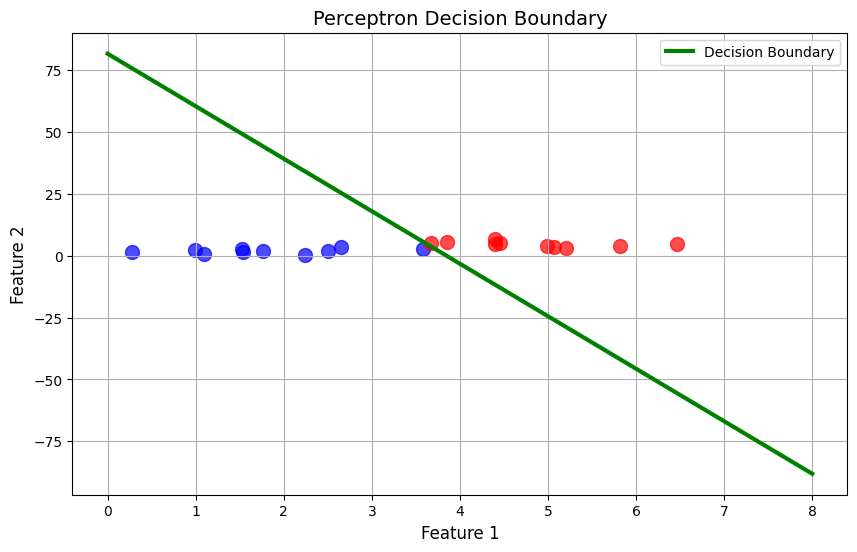

In [ ]:
# ============================================
# STEP 5: VISUALIZE DECISION BOUNDARY
# ============================================
print("\nSTEP 5: Plotting decision boundary...")

plt.figure(figsize=(10, 6))

# Plot points
for i in range(len(X)):
    if y[i] == 0:
        plt.scatter(X[i,0], X[i,1], color='blue', s=100, alpha=0.7)
    else:
        plt.scatter(X[i,0], X[i,1], color='red', s=100, alpha=0.7)

# Draw decision line
# Line equation: w1*x1 + w2*x2 + b = 0
# Solve for x2: x2 = -(w1*x1 + b) / w2

x1_line = np.linspace(0, 8, 100)
x2_line = -(w1 * x1_line + b) / w2

plt.plot(x1_line, x2_line, 'g-', linewidth=3, label='Decision Boundary')

plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('Perceptron Decision Boundary', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================
# STEP 6: TEST NEW POINTS
# ============================================
print("\nSTEP 6: Testing new points...")

test_points = [[3, 3], [6, 6], [2, 5], [5, 2]]

for point in test_points:
    x1 = point[0]
    x2 = point[1]

    output = w1 * x1 + w2 * x2 + b

    if output >= 0:
        prediction = 1
    else:
        prediction = 0

    print(f"Point ({x1}, {x2}) → Class {prediction}")


STEP 6: Testing new points...
Point (3, 3) → Class 0
Point (6, 6) → Class 1
Point (2, 5) → Class 0
Point (5, 2) → Class 1


#**Tasks**
- **Task 1:** Run and Understand the Code
    - Observe: Which converges faster? Which is more stable?
- **Task 2:** Modify the Dataset. Change the cluster centers from (2,2) and (5,5) to:
    - (1,1) and (3,3) - closer together
    - (0,0) and (10,10) - farther apart
- **Task 3:** Change Number of Points
    - Try with 50 points per class (100 total)
    - Does more data help or hurt accuracy?







